# Online Dataset Collector

The two datasets links:
* https://www.kaggle.com/datasets/shivampandey1233/drowsy-dataset
* https://universe.roboflow.com/neurosense/user-attention
* https://universe.roboflow.com/distractless/distractless
* https://universe.roboflow.com/distracteddetection/distracted_detection

Potential Test Dataset:
* https://universe.roboflow.com/bklab/students-in-lecture
* https://universe.roboflow.com/123-cpztz/ml-pjutg
* https://universe.roboflow.com/studentclassroomanalytics/deepdiveconsulting-classroom-analysis

Downloads and processes two online engagement datasets, extracts facial landmark features per image, and saves to `labeled_features.csv`.

**Output columns:** `ear_left, ear_right, ear_avg, mar, pitch, yaw, roll, perclos, blink_rate, label`

Labels: `0 = ATTENTIVE` | `1 = SLEEPY` | `2 = DISTRACTED`

---

## Step 1: Setup & Installing Dependencies

Only run once

In [ ]:
!pip install mediapipe opencv-python roboflow kaggle matplotlib pandas

In [ ]:
!pip install "numpy<2.0"

In [ ]:
import cv2
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
from pathlib import Path
from roboflow import Roboflow

---

## Step 2: Detect Environment & Mounting Dataset

Check if its being run on Google.Colab or run on local device

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ON_COLAB = True
    print('Running on Google Colab.')
except ImportError:
    ON_COLAB = False
    print('Running locally.')

---

## Step 3: Configuration

## Step 3: Configuration

API credentials can be obtained as below:

| Key | Where to get it |
|---|---|
| `KAGGLE_USERNAME` | kaggle.com → Profile → Account → Username |
| `KAGGLE_KEY` | kaggle.com → Settings → API → **Create New Token** → copy the `key` value from the downloaded JSON |
| `ROBOFLOW_API_KEY` | roboflow.com → Account → Roboflow API → Private API Key |

label
DISTRACTED    752
ATTENTIVE     752
SLEEPY        752
Name: count, dtype: int64


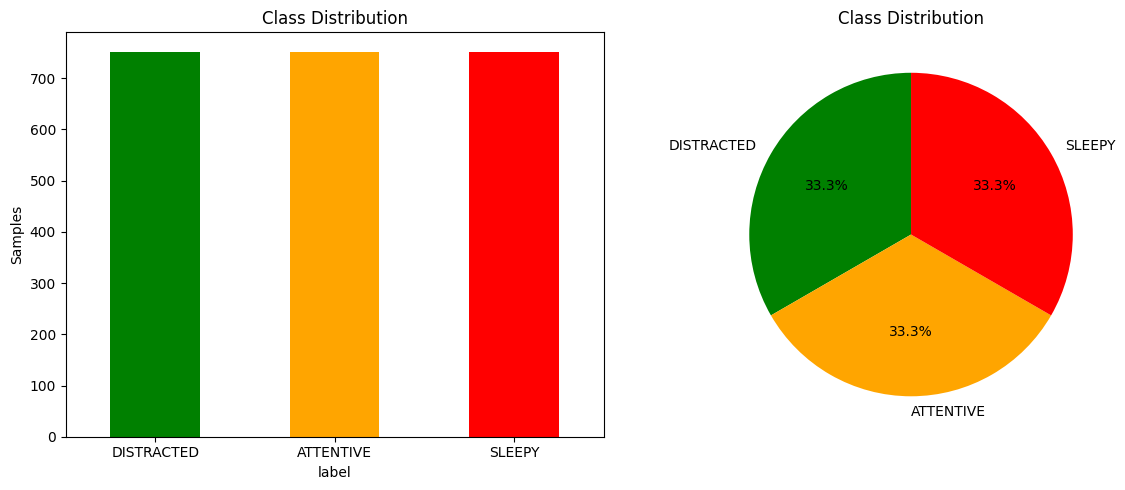

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Resolves correctly whether Jupyter is run from project root or notebook dir
ROOT = Path().resolve()
candidates = [ROOT / 'data' / 'labeled_features.csv',
              ROOT.parents[2] / 'data' / 'labeled_features.csv']
csv_path = next((p for p in candidates if p.exists()), None)

if csv_path is None:
    raise FileNotFoundError("labeled_features.csv not found — run collect_from_datasets.py first")

df = pd.read_csv(csv_path)
counts = df['label'].map({0: 'ATTENTIVE', 1: 'SLEEPY', 2: 'DISTRACTED'}).value_counts()
print(counts)

colors = ['green', 'orange', 'red']

fig, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(12, 5))

counts.plot(kind='bar', color=colors, ax=ax_bar)
ax_bar.set_title('Class Distribution')
ax_bar.set_ylabel('Samples')
ax_bar.tick_params(axis='x', rotation=0)

ax_pie.pie(counts, labels=counts.index, colors=colors,
           autopct='%1.1f%%', startangle=90)
ax_pie.set_title('Class Distribution')

plt.tight_layout()
plt.savefig(csv_path.parent / 'class_distribution.png')
plt.show()
